In [50]:
!pip3 install numpy matplotlib seaborn scikit-image scikit-learn mlxtend


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Ryuk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# **1. Dataset Preparation**

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.data import loadlocal_mnist

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import ParameterGrid

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [52]:
images, labels = loadlocal_mnist(
    images_path=r'C:\Users\Ryuk\OneDrive\Documents\Semester 6\Computer Vision\UTS\dataset\emnist-letters-train-images-idx3-ubyte',
    
    labels_path=r'C:\Users\Ryuk\OneDrive\Documents\Semester 6\Computer Vision\UTS\dataset\emnist-letters-train-labels-idx1-ubyte'
)

In [53]:
print("Shape Images :", images.shape)
print("Shape Labels :", labels.shape)

Shape Images : (124800, 784)
Shape Labels : (124800,)


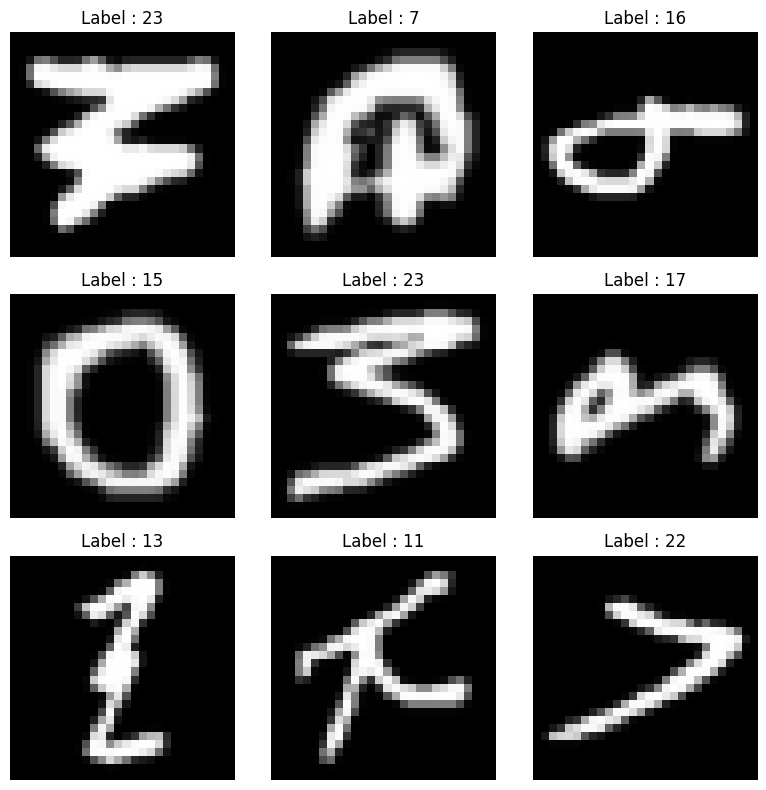

In [54]:
plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    image = images[i].reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(f'Label : {labels[i]}')

    plt.axis('off')

plt.tight_layout()
plt.show()

In [55]:
labels = labels - 1

In [56]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [57]:
samples_per_class = 20

selected_images = []
selected_labels = []

In [58]:
for label in range(26):

    idx = np.where(labels == label)[0][:samples_per_class]

    selected_images.append(images[idx])

    selected_labels.append(labels[idx])

In [59]:
X = np.vstack(selected_images)

y = np.hstack(selected_labels)

print(X.shape)
print(y.shape)

(520, 784)
(520,)


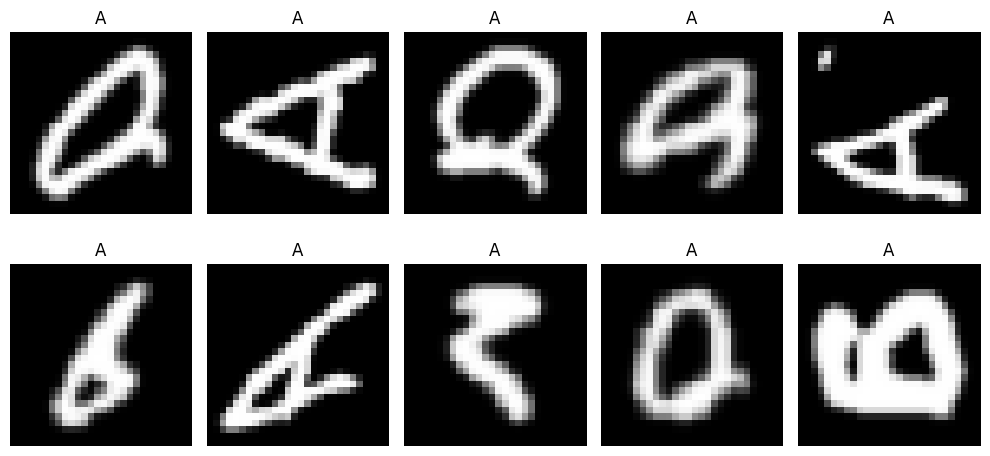

In [60]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = X[i].reshape(28,28)

    plt.imshow(image, cmap='gray')

    plt.title(letters[y[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

# **2. Feature Extraction**

In [61]:
def extract_hog_features(images,
                         orientations,
                         pixels_per_cell,
                         cells_per_block):

    hog_features = []

    for image in images:

        image = image.reshape(28,28)

        features = hog(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys'
        )

        hog_features.append(features)

    return np.array(hog_features)

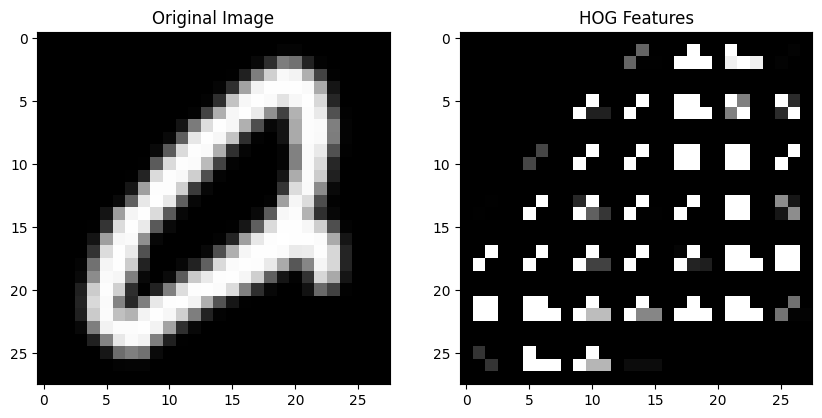

In [62]:
sample_image = X[0].reshape(28,28)

features, hog_image = hog(
    sample_image,
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    block_norm='L2-Hys',
    visualize=True
)

hog_image = exposure.rescale_intensity(
    hog_image,
    in_range=(0,10)
)

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].imshow(sample_image, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(hog_image, cmap='gray')
ax[1].set_title("HOG Features")

plt.show()

In [63]:
hog_params = {
    'orientations': 9,
    'pixels_per_cell': (4,4),
    'cells_per_block': (2,2)
}

In [64]:
X_hog = extract_hog_features(
    X,
    orientations=hog_params['orientations'],
    pixels_per_cell=hog_params['pixels_per_cell'],
    cells_per_block=hog_params['cells_per_block']
)

print(X_hog.shape)

(520, 1296)


# **3. Classification**

In [65]:
param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

In [66]:
loo = LeaveOneOut()

In [67]:
best_accuracy = 0
best_model = None
best_params = None
best_y_true = None
best_y_pred = None

In [68]:
best_accuracy = 0
best_model = None
best_params = None
best_y_true = None
best_y_pred = None

In [69]:
for params in ParameterGrid(param_grid):

    print("Testing Parameter :", params)

    y_true = []
    y_pred = []

    model = SVC(
        C=params['C'],
        kernel=params['kernel'],
        gamma=params['gamma']
    )

    for train_index, test_index in loo.split(X_hog):

        X_train, X_test = X_hog[train_index], X_hog[test_index]

        y_train, y_test = y[train_index], y[test_index]

        model.fit(X_train, y_train)

        prediction = model.predict(X_test)

        y_true.append(y_test[0])

        y_pred.append(prediction[0])

    accuracy = accuracy_score(y_true, y_pred)

    print("Accuracy :", accuracy)

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_params = params

        best_y_true = y_true

        best_y_pred = y_pred

Testing Parameter : {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy : 0.7019230769230769
Testing Parameter : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy : 0.6884615384615385
Testing Parameter : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy : 0.7019230769230769
Testing Parameter : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy : 0.7288461538461538


# **4. Evaluation**

In [70]:
print("\nBest Parameters :")
print(best_params)

print("\nBest Accuracy :")
print(best_accuracy)


Best Parameters :
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Accuracy :
0.7288461538461538


In [71]:
accuracy = accuracy_score(best_y_true, best_y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7288461538461538


In [72]:
precision = precision_score(
    best_y_true,
    best_y_pred,
    average='weighted'
)

print("Precision :", precision)

Precision : 0.7338404826653582


In [73]:
f1 = f1_score(
    best_y_true,
    best_y_pred,
    average='weighted'
)

print("F1-Score :", f1)

F1-Score : 0.7294913665130516


In [74]:
report = classification_report(
    best_y_true,
    best_y_pred,
    target_names=list(letters)
)

print(report)

              precision    recall  f1-score   support

           A       0.32      0.40      0.36        20
           B       0.64      0.70      0.67        20
           C       0.68      0.75      0.71        20
           D       0.80      0.80      0.80        20
           E       0.80      0.80      0.80        20
           F       0.84      0.80      0.82        20
           G       0.45      0.45      0.45        20
           H       0.74      0.85      0.79        20
           I       0.63      0.60      0.62        20
           J       0.79      0.75      0.77        20
           K       0.89      0.85      0.87        20
           L       0.53      0.45      0.49        20
           M       0.76      0.80      0.78        20
           N       0.62      0.65      0.63        20
           O       0.81      0.85      0.83        20
           P       0.77      0.85      0.81        20
           Q       0.73      0.55      0.63        20
           R       0.75    

In [75]:
cm = confusion_matrix(
    best_y_true,
    best_y_pred
)

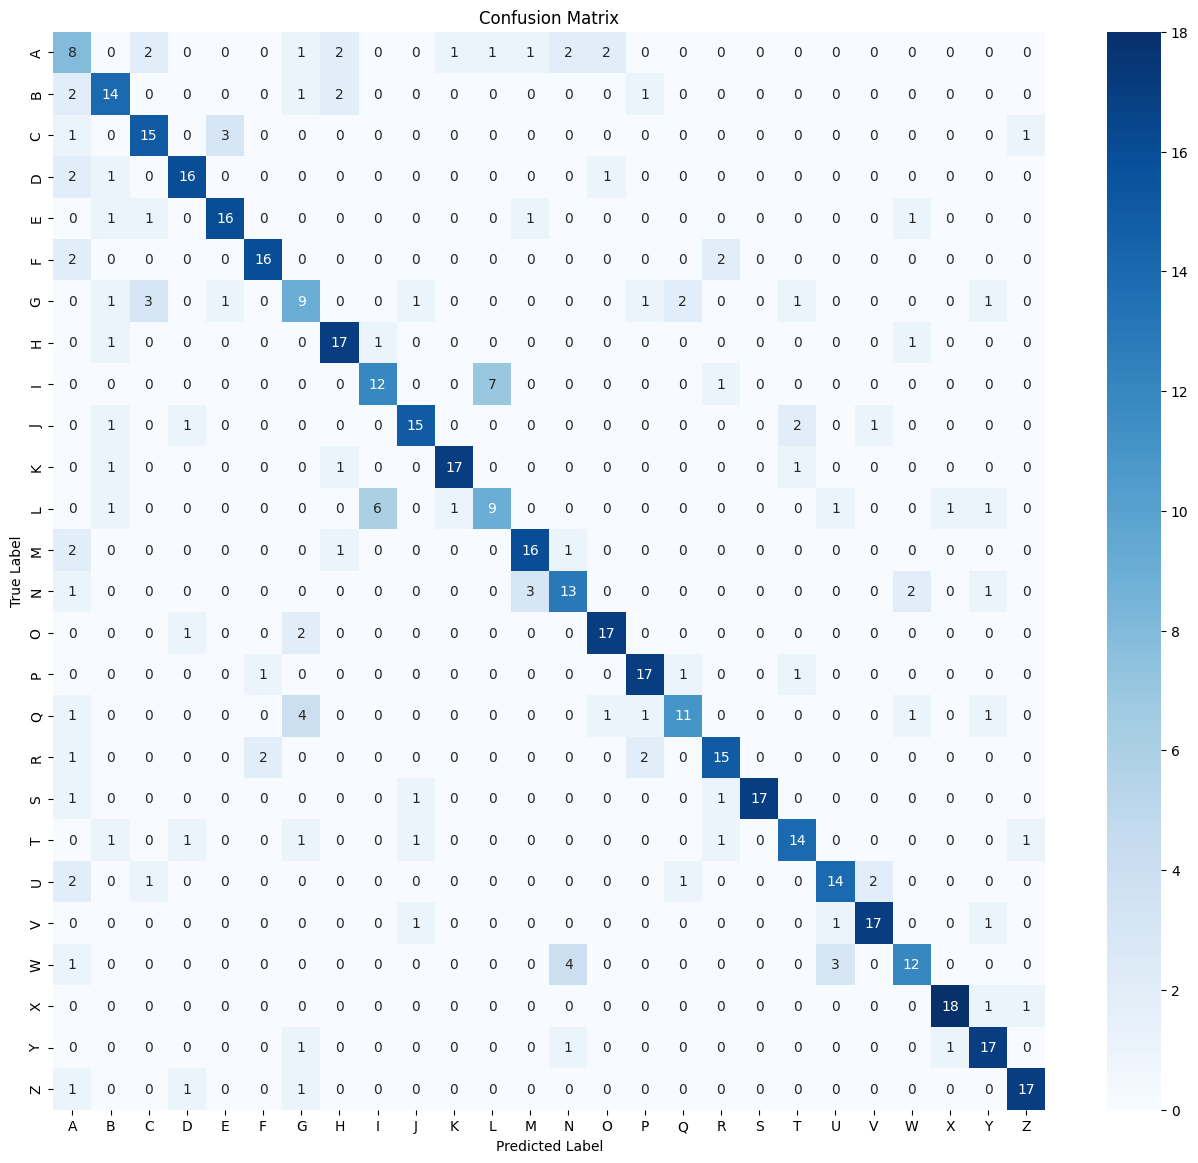

In [76]:
plt.figure(figsize=(16,14))

sns.heatmap(

    cm,

    annot=True,         

    fmt='d',             

    cmap='Blues',        

    xticklabels=list(letters),

    yticklabels=list(letters)
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

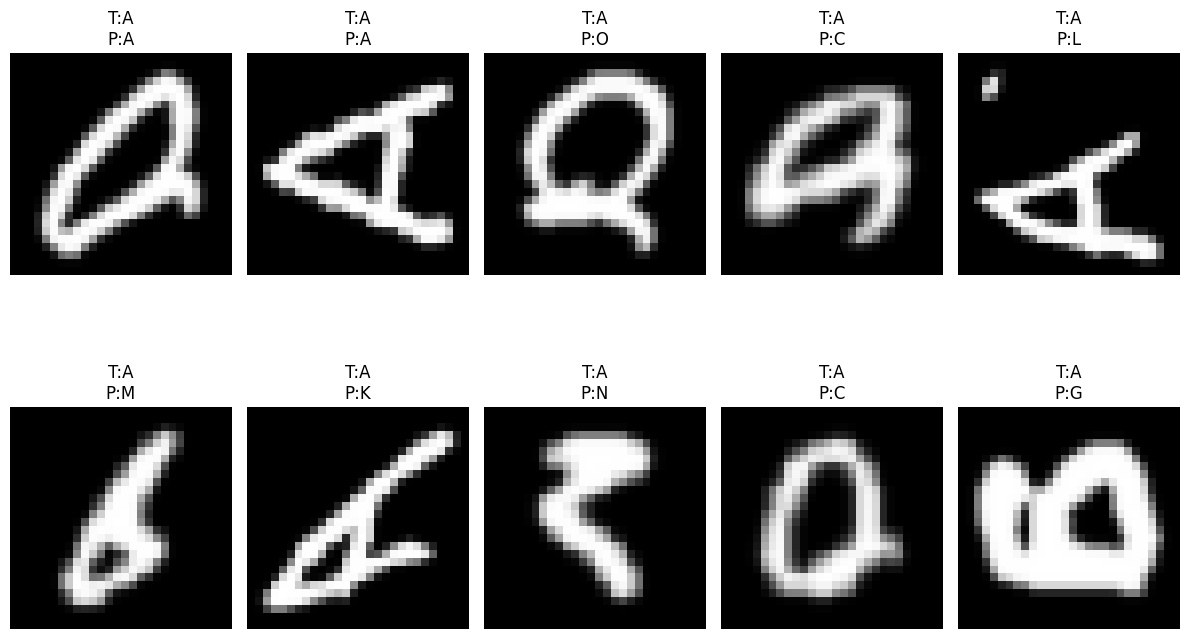

In [77]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = X[i].reshape(28,28)

    plt.imshow(image, cmap='gray')

    true_label = letters[best_y_true[i]]

    pred_label = letters[best_y_pred[i]]

    plt.title(f'T:{true_label}\nP:{pred_label}')

    plt.axis('off')

plt.tight_layout()
plt.show()

In [78]:
joblib.dump(best_model, 'emnist_hog_svm_loocv.pkl')

['emnist_hog_svm_loocv.pkl']

In [79]:
loaded_model = joblib.load(
    'emnist_hog_svm_loocv.pkl'
)

In [80]:
new_image = X[0].reshape(28,28)

features = hog(
    new_image,
    orientations=9,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2),
    block_norm='L2-Hys'
)

prediction = loaded_model.predict([features])[0]

print("Predicted Letter :",
      letters[prediction])

Predicted Letter : A
